<a href="https://colab.research.google.com/github/marina04-dev/Jupyter_Notebooks/blob/main/Diabetes_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predicting** **Diabetes** **Using** **Machine** **Learning**


---
### **Description**


---
This dataset is originally from the National Institute of Diabetes and Digestive Kidney Diseases. The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.





### **Content**

The datasets consists of several medical predictor variables and one target variable, outcome. Predictor variables includes the number of pregnancies the patient has had, their BMI, insulin level, age and so on.

### **Acknowledgments**

Smith, J.W., Everhart, J.E., Dickson, W.C., Knowler, W.C., & Johannes, R.S. (1988). Using the ADAP Learning Algorithm to forecast the onset of diabetes mellitus. In Proceedings of the Symposium on Computer Applications and Medical Care (pp. 261--265). IEEE Computer Society Press.

### **Problem** **Statement**

By using these patient records, we will try to build a machine learning model to accurately predict whether or not the patients in the dataset have diabetes or not.

### **Data** **Description**

Columns:

  - Pregnancies:  Number of times pregnant
  - Glucose:  Plasma glucose concentration a 2 hours in an oral glucose tolerance test
  - BloodPressure:  Diastolic blood pressure (mm Hg)
  - SickThickness:  Triceps skin fold thickness (mm)
  - Insulin:  2-Hour serum insulin (mu U/ml)
  - BMI:  Body mass index (weight in kg/(height in m)^2)
  - DiabetesPedigreeFunction:  Diabetes pedigree function
  - Age:  Age (years)
  - Outcome:  Class variable (0 or 1) 268 of 768 are 1, the others are 0.


### **Business** **Objectives** **&** **Constraints**

1. The cost of a mis-classification can be very very high.
2. There is no strict latency concerns.
3. Because this project is from health domain, so we have to be very cautious about the results/outcomes.

### **Importing Libraries**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from mlxtend.plotting import plot_decision_regions
import missingno as msno
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

### **Reading** **the** **Data** **from** **the** **CSV** **file**

In [4]:
df = pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


### **Exploratory** **Data** **Analysis**

In [5]:
# Total number of columns in the dataset
print('Total number of columns in the dataset: ', len(df.columns))

# Information about the dataset
print('\nInformation about the dataset: \n', df.info())

# More about the dataset, with transpose
print('\nMore about the dataset, with transpose: \n', df.describe().transpose())

# Checking if there are null/missing values or not
print('\nTotal Null/missing values: ', df.isnull().sum())


Total number of columns in the dataset:  9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Information about the dataset: 
 None

More about the dataset, with transpose: 
                           count        mean         std     min       25%  \
Pregnancies               768.0    3.8

On these columns, a value of zero does not make sense and thus indicates missing value/s.

Following columns or variables have invalid zero value/s:
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI

It is better to replace zeros with NAN since after that, counting them would be easier and zeros need to be replaced with suitable values.

In [7]:
data = df.copy(deep=True)
data.columns = ['pregnancies', 'glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi', 'diabetes_pedigree_function', 'age', 'outcome']
data

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [18]:
data[['glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi']] = data[['glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi']].replace(0, np.nan)

# Showing the count of NaNs
print('Total Missing Values:\n', data.isna().sum())

Total Missing Values:
 pregnancies                   0
glucose                       0
blood_pressure                0
skin_thickness                0
insulin                       0
bmi                           0
diabetes_pedigree_function    0
age                           0
outcome                       0
dtype: int64


### **Data** **Visualization**

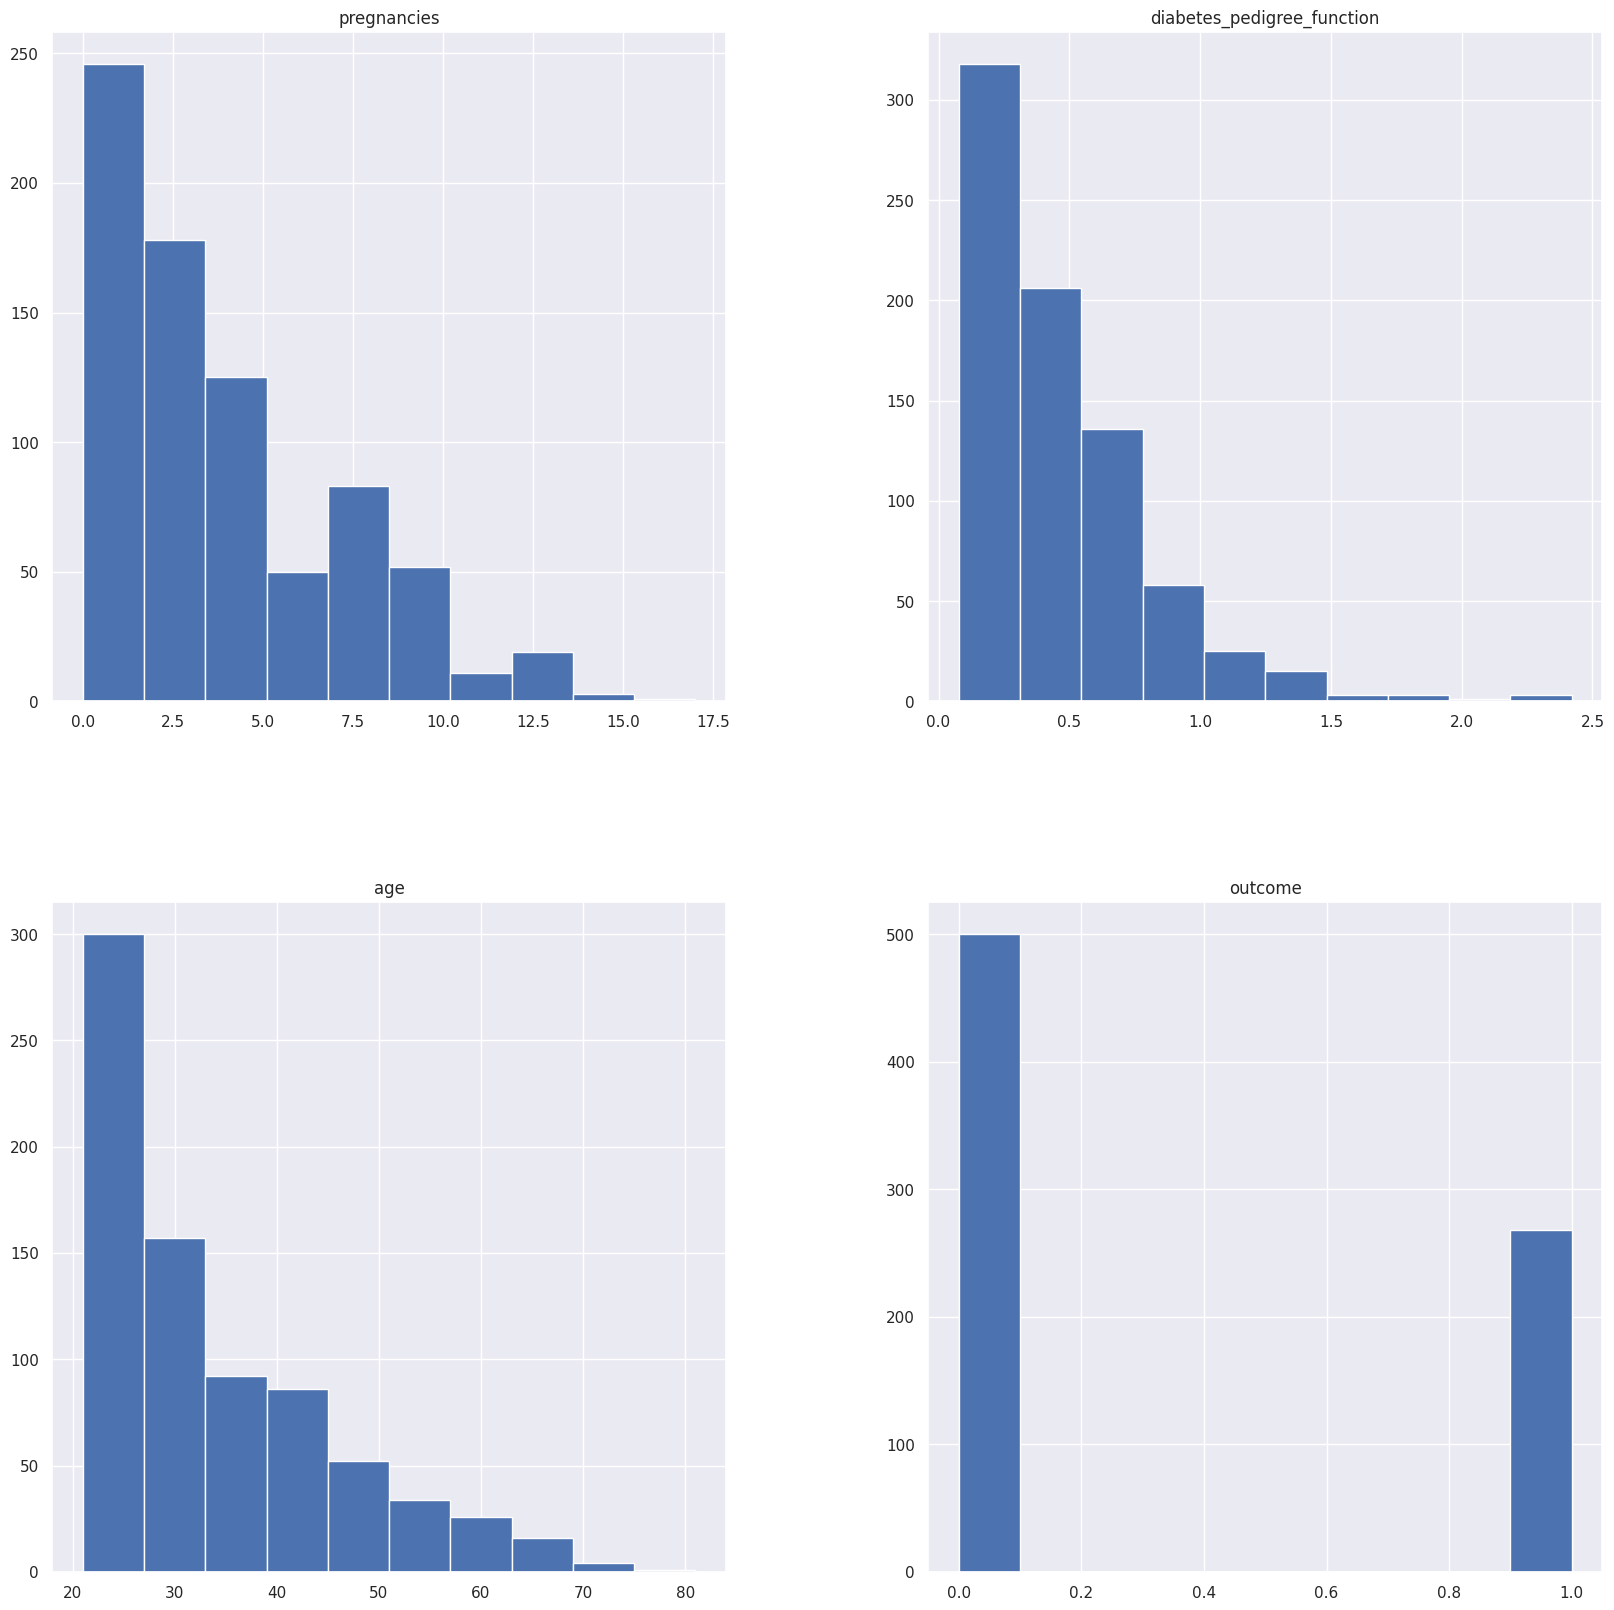

In [19]:
# Plotting data distribution plot
p = data.hist(figsize=(20,20))

outcome
0    500
1    268
Name: count, dtype: int64


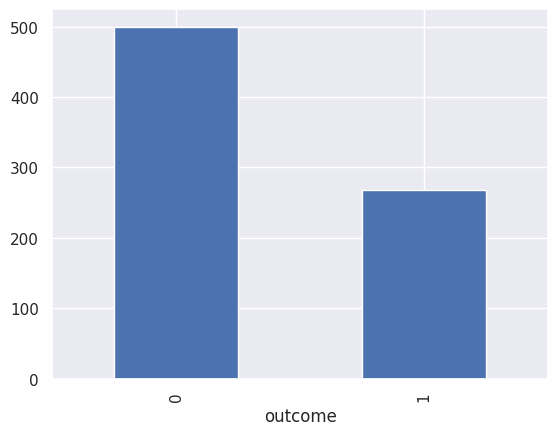

In [20]:
# Checking the balance of the data by plotting the count of outcomes by their values
color_wheel = {1: "#0392cf",
               0: "#7bc043"}
colors = data['outcome'].map(lambda x: color_wheel.get(x + 1))
print(data['outcome'].value_counts())
p = data['outcome'].value_counts().plot(kind='bar')

The above graph shows that the data is biased towards data points having outcome value as 0 where it means that diabetes was not present actually. The number of non-diabetics is almost twice of diabetic patients.

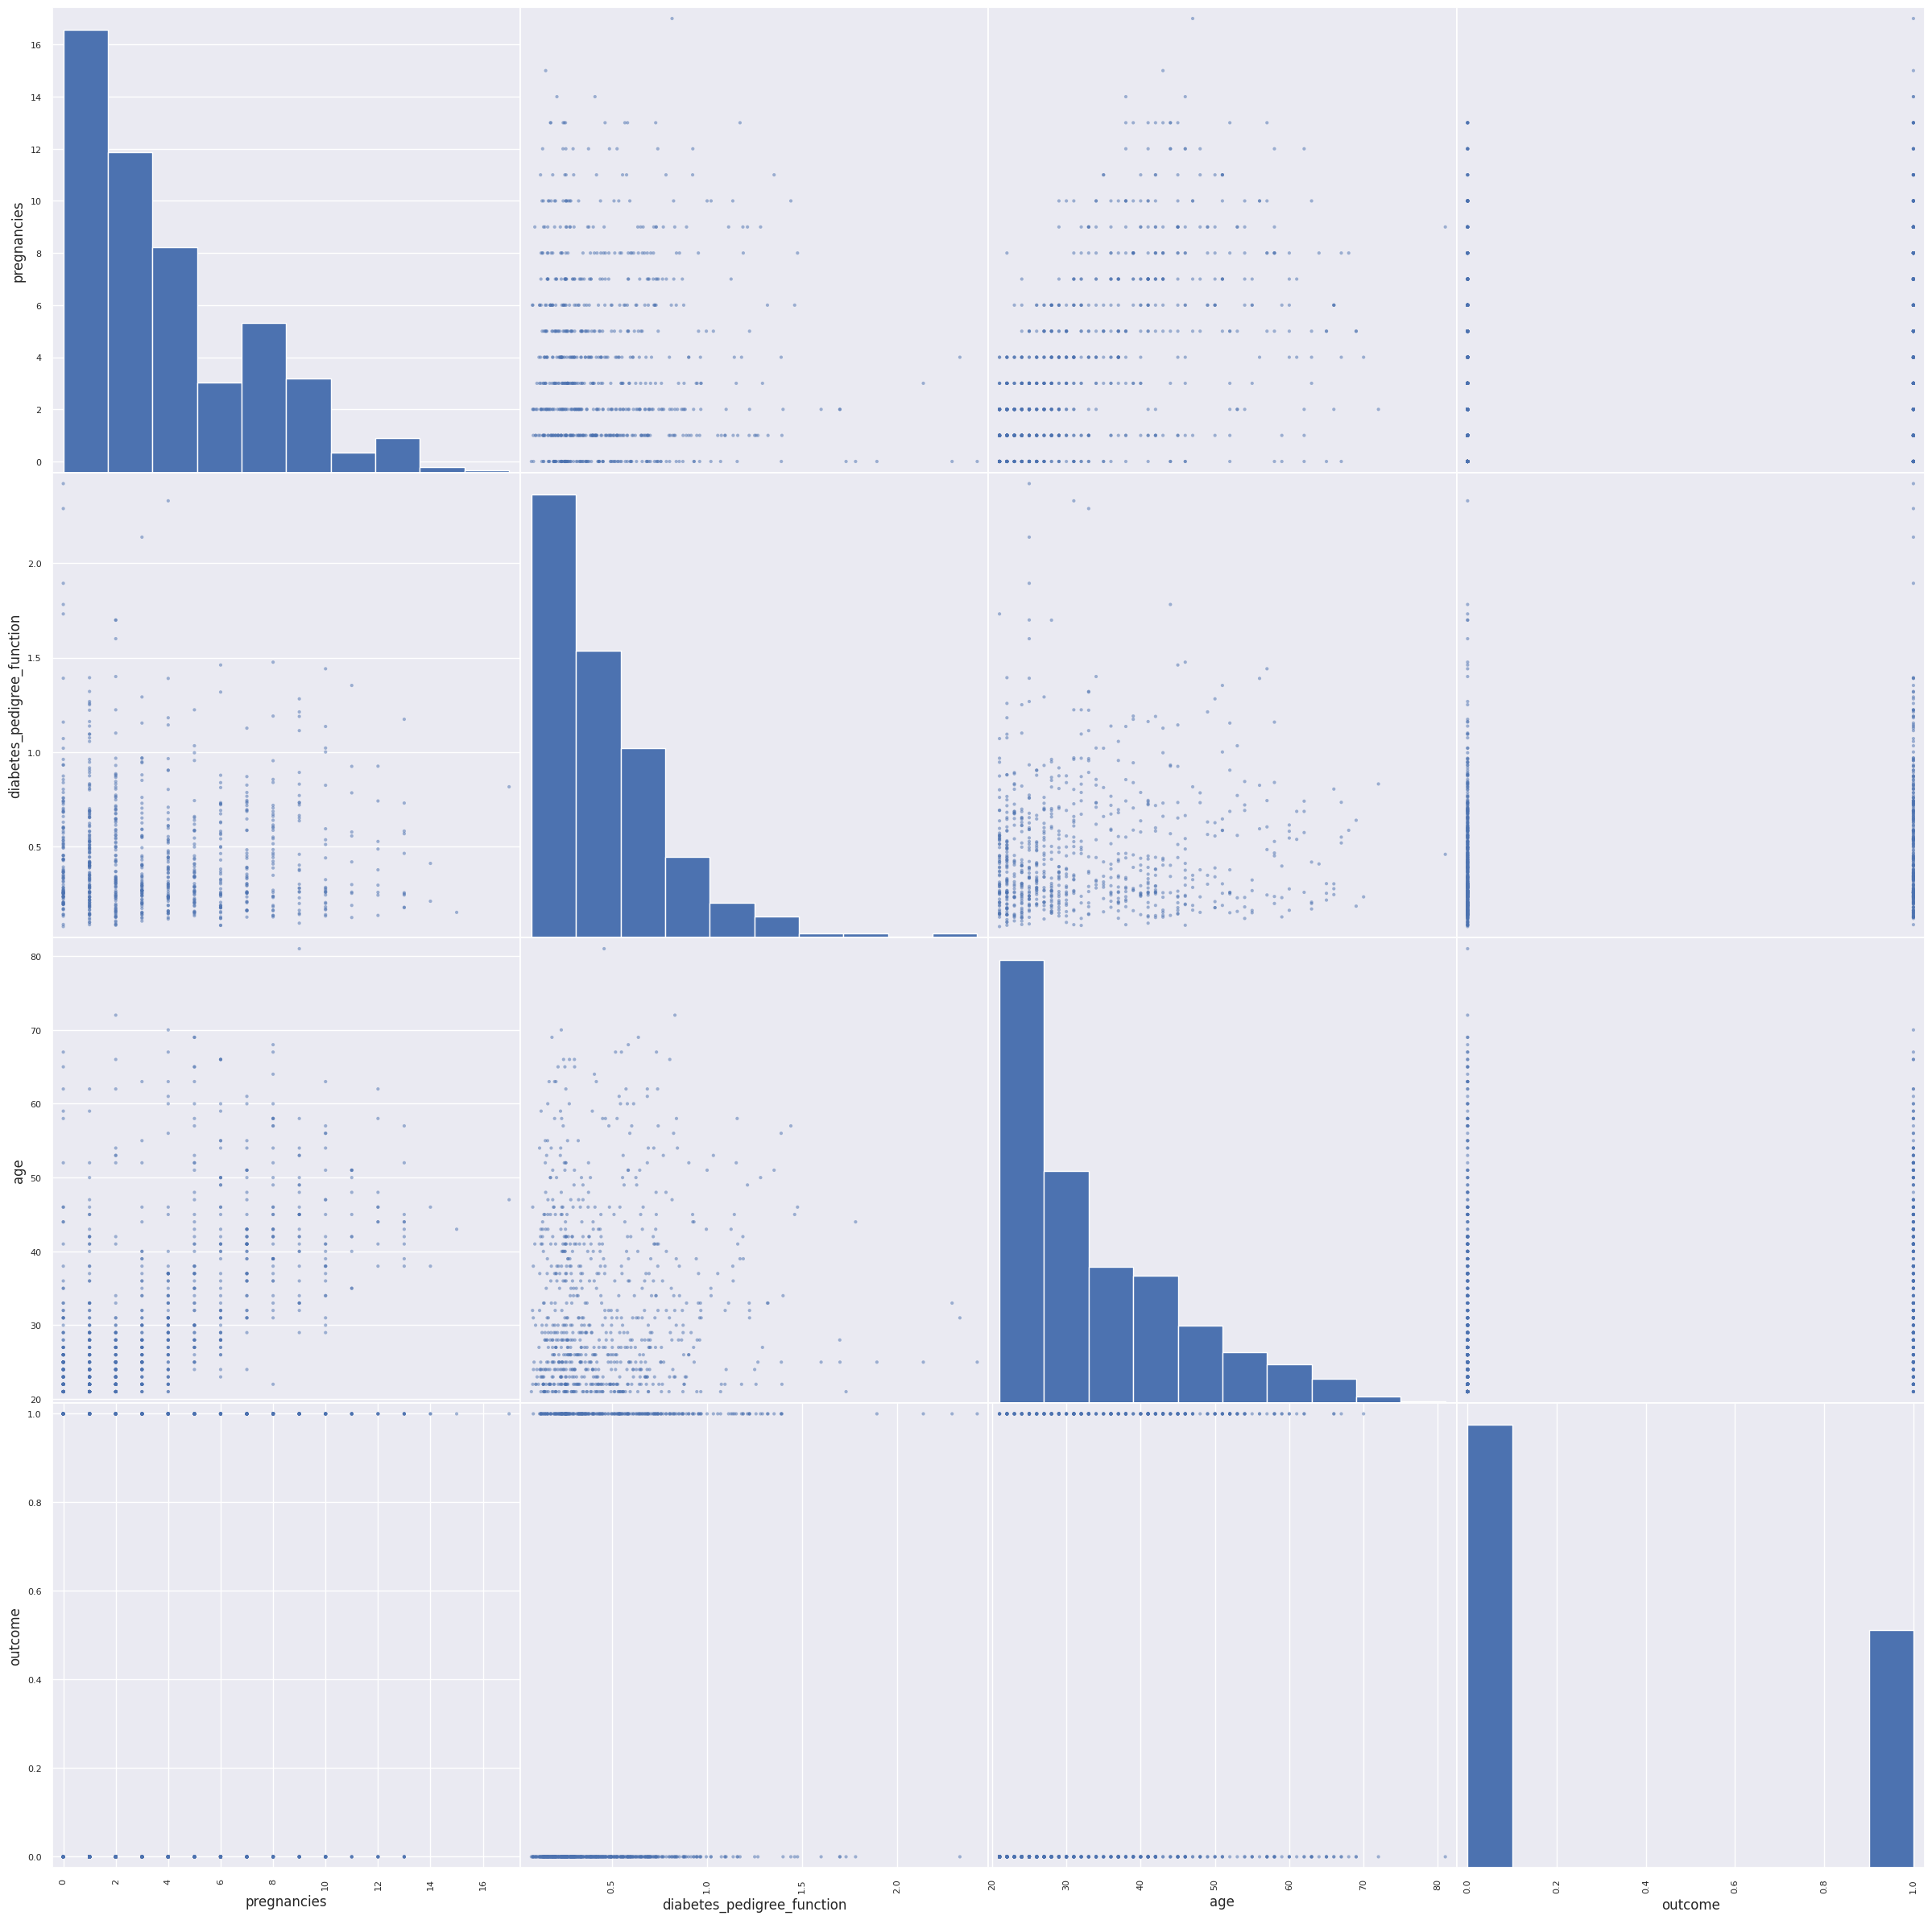

In [21]:
# Plotting a scatter matrix of the data
p = scatter_matrix(data, figsize=(30,30))

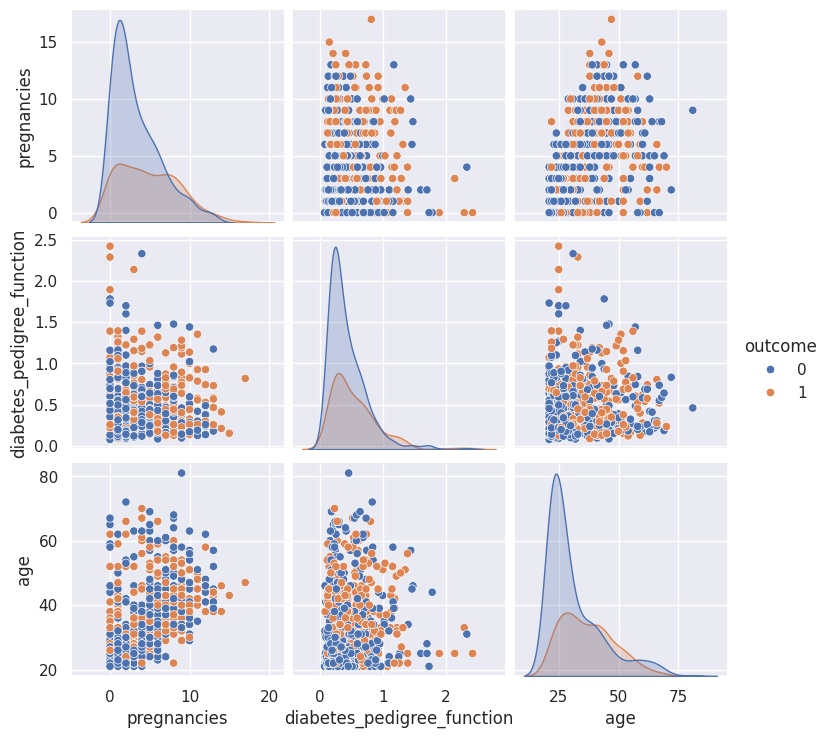

In [22]:
# Plotting the pair plots for the data
p = sns.pairplot(data, hue='outcome')

### **Correlation** **Between** **All** **Features**

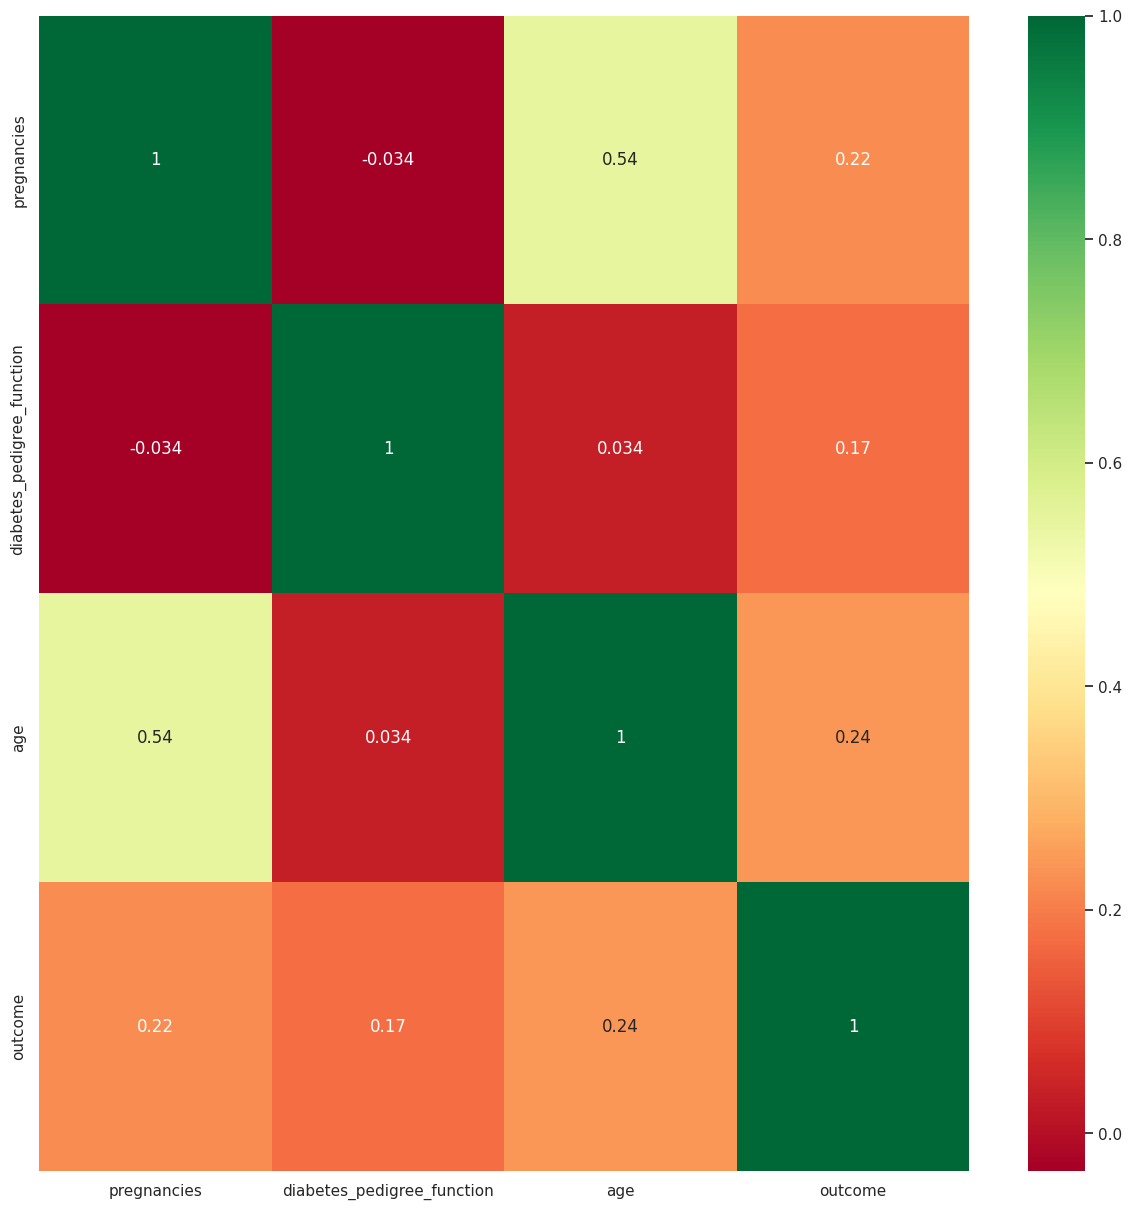

In [25]:
# Correlation between all the features of the data
plt.figure(figsize=(15,15))
p = sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='RdYlGn')

In [28]:
# Get columns with object dtype
object_cols = data.select_dtypes(include='object').columns

# Try to convert object columns to numeric
for col in object_cols:
    # Attempt to convert to numeric, coercing errors to NaN
    data[col] = pd.to_numeric(data[col], errors='coerce')

    # Check if there are any NaN values introduced by coercion
    if data[col].isnull().any():
        print(f"Column '{col}' contains non-numeric values that were converted to NaN.")
    else:
        # If no NaNs, try to convert to integer if possible
        if all(data[col] == data[col].astype(int)):
            data[col] = data[col].astype(int)
        print(f"Column '{col}' successfully converted to numeric type.")

# Display the data types after conversion
print("\nData types after conversion:")
print(data.info())

Column 'glucose' contains non-numeric values that were converted to NaN.
Column 'blood_pressure' contains non-numeric values that were converted to NaN.
Column 'skin_thickness' contains non-numeric values that were converted to NaN.
Column 'insulin' contains non-numeric values that were converted to NaN.
Column 'bmi' contains non-numeric values that were converted to NaN.

Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   pregnancies                 768 non-null    int64  
 1   glucose                     763 non-null    float64
 2   blood_pressure              733 non-null    float64
 3   skin_thickness              541 non-null    float64
 4   insulin                     394 non-null    float64
 5   bmi                         757 non-null    float64
 6   diabetes_pedigree_function  76

In [30]:
# Check for missing values before imputation
print("Missing values before imputation:")
print(data.isnull().sum())

# Impute missing values with the mean of each column
for col in data.columns:
    if data[col].isnull().any(): # Check if there are any missing values in the column
        mean_value = data[col].mean()
        data[col].fillna(mean_value, inplace=True)
        print(f"Missing values in column '{col}' replaced with its mean ({mean_value:.2f}).")

# Verify that there are no more missing values
print("\nMissing values after imputation:")
print(data.isnull().sum())

# Display the info to confirm non-null counts
print("\nDataFrame info after imputation:")
print(data.info())

Missing values before imputation:
pregnancies                     0
glucose                         5
blood_pressure                 35
skin_thickness                227
insulin                       374
bmi                            11
diabetes_pedigree_function      0
age                             0
outcome                         0
dtype: int64
Missing values in column 'glucose' replaced with its mean (121.69).
Missing values in column 'blood_pressure' replaced with its mean (72.41).
Missing values in column 'skin_thickness' replaced with its mean (29.15).
Missing values in column 'insulin' replaced with its mean (155.55).
Missing values in column 'bmi' replaced with its mean (32.46).

Missing values after imputation:
pregnancies                   0
glucose                       0
blood_pressure                0
skin_thickness                0
insulin                       0
bmi                           0
diabetes_pedigree_function    0
age                           0
outcome   

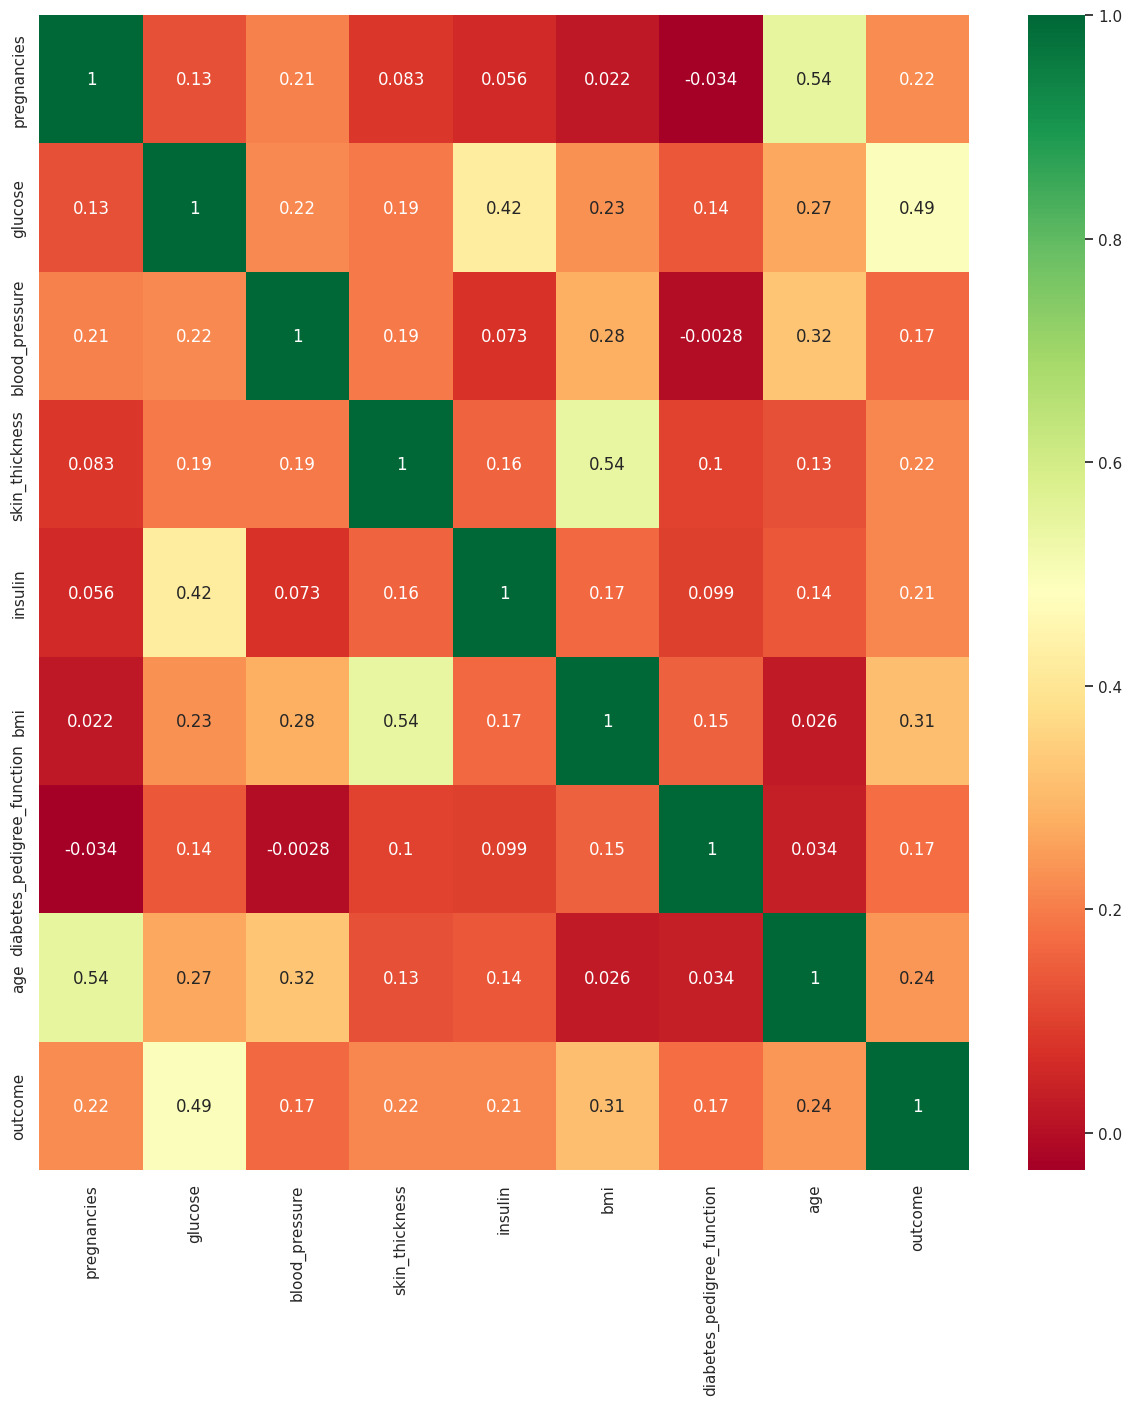

In [31]:
# Correlation between all features after cleaning and data type convertion
plt.figure(figsize=(15,15))
p = sns.heatmap(data.corr(), annot=True, cmap='RdYlGn')

### **Scaling** **The** **Data**

In [32]:
scaler_X = StandardScaler()
X = pd.DataFrame(scaler_X.fit_transform(data.drop('outcome', axis=1)), columns=data.drop('outcome', axis=1).columns)
X

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age
0,0.639947,0.865108,-0.033518,6.655021e-01,-3.345079e-16,0.166292,0.468492,1.425995
1,-0.844885,-1.206162,-0.529859,-1.746338e-02,-3.345079e-16,-0.852531,-0.365061,-0.190672
2,1.233880,2.015813,-0.695306,8.087936e-16,-3.345079e-16,-1.332833,0.604397,-0.105584
3,-0.844885,-1.074652,-0.529859,-7.004289e-01,-7.243887e-01,-0.634212,-0.920763,-1.041549
4,-1.141852,0.503458,-2.680669,6.655021e-01,1.465506e-01,1.548980,5.484909,-0.020496
...,...,...,...,...,...,...,...,...
763,1.827813,-0.680125,0.297376,2.145261e+00,2.877840e-01,0.064409,-0.908682,2.532136
764,-0.547919,0.010298,-0.198965,-2.451185e-01,-3.345079e-16,0.632039,-0.398282,-0.531023
765,0.342981,-0.022579,-0.033518,-7.004289e-01,-5.125386e-01,-0.910750,-0.685193,-0.275760
766,-0.844885,0.141808,-1.026200,8.087936e-16,-3.345079e-16,-0.343120,-0.371101,1.170732


In [33]:
y = data.outcome
y

,outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


### **Splitting** **The** **Data** **Into** **Train** **&** **Test**

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=42, stratify=y)

### **Model** **Building**


### **K-Nearest** **Neighbor** **(KNN)**

In [35]:
test_scores = []
train_scores = []

for i in range(1,15):
  knn = KNeighborsClassifier(i)
  knn.fit(X_train, y_train)

  train_scores.append(knn.score(X_train, y_train))
  test_scores.append(knn.score(X_test, y_test))

print("Train Scores:\n", train_scores)
print("\nTest Scores:\n", test_scores)

Train Scores:
 [1.0, 0.84765625, 0.865234375, 0.83203125, 0.8359375, 0.806640625, 0.81640625, 0.8046875, 0.802734375, 0.79296875, 0.80859375, 0.794921875, 0.796875, 0.79296875]

Test Scores:
 [0.7265625, 0.73046875, 0.75390625, 0.74609375, 0.734375, 0.7265625, 0.74609375, 0.73046875, 0.73046875, 0.72265625, 0.76171875, 0.7265625, 0.75390625, 0.73828125]


In [36]:
max_train_score = max(train_scores)
max_test_score = max(test_scores)
max_train_score_index = train_scores.index(max_train_score)
max_test_score_index = test_scores.index(max_test_score)
print("Max train score {} % and k = {}".format(max_train_score*100, max_train_score_index+1))
print("Max test score {} % and k = {}".format(max_test_score*100, max_test_score_index+1))

Max train score 100.0 % and k = 1
Max test score 76.171875 % and k = 11


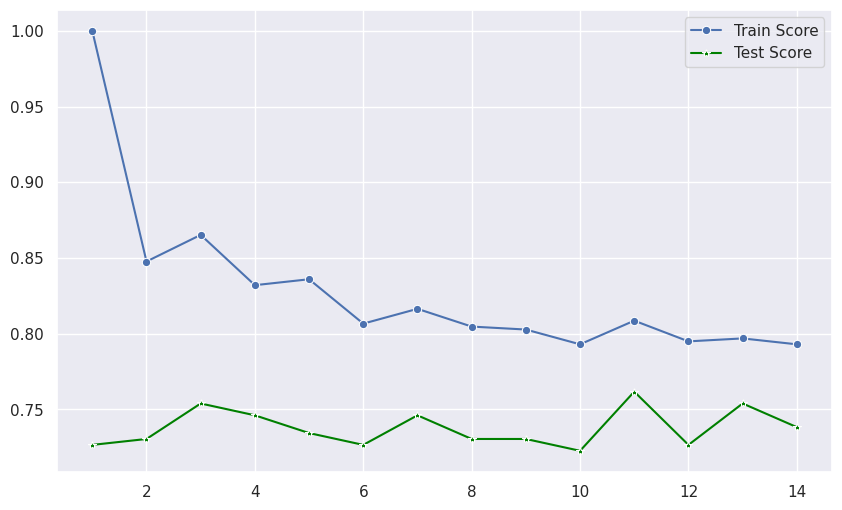

In [39]:
plt.figure(figsize=(10,6))
p = sns.lineplot(x=range(1,15),y=train_scores, marker = 'o',label='Train Score')
p = sns.lineplot(x=range(1,15),y=test_scores,color = 'green', marker='*', label='Test Score')

The best result is captured at k=11 hence 11 is used for the final model

In [40]:
knn = KNeighborsClassifier(11)
knn.fit(X_train, y_train)
knn.score(X_test, y_test)

0.76171875

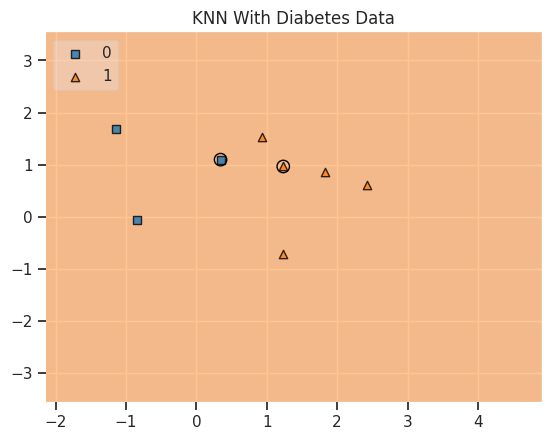

In [42]:
# Plot the decision boundary
value = 20000
width = 20000
plot_decision_regions(X.values, y.values, clf=knn, legend=2,
                      filler_feature_values={2: value, 3: value, 4: value, 5: value, 6: value, 7: value},
                      filler_feature_ranges={2: width, 3: width, 4: width, 5: width, 6: width, 7: width},
                      X_highlight=X_test.values)
plt.title('KNN With Diabetes Data')
plt.show()

### **Confusion** **Matrix**

Text(0.5, 19.049999999999997, 'Predicted label')

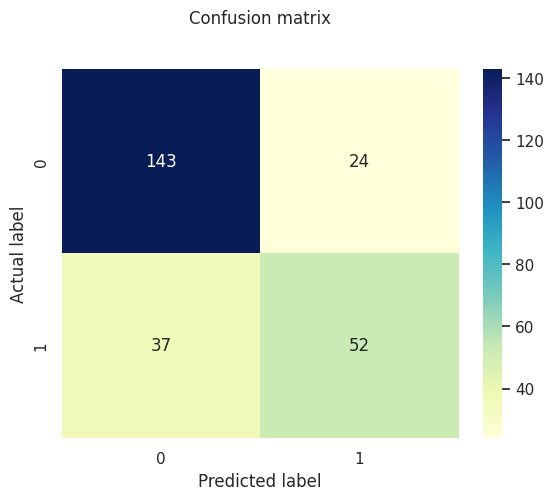

In [43]:
y_pred = knn.predict(X_test)
cm = metrics.confusion_matrix(y_test, y_pred)
p = sns.heatmap(pd.DataFrame(cm), annot=True, cmap="YlGnBu" ,fmt='g')
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [44]:
# Classification Reports
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.86      0.82       167
           1       0.68      0.58      0.63        89

    accuracy                           0.76       256
   macro avg       0.74      0.72      0.73       256
weighted avg       0.76      0.76      0.76       256



### **ROC**-**AUC** **Curve**

In [45]:
y_pred_proba = knn.predict_proba(X_test)[::,1]
fpr, tpr, _ = roc_curve(y_test,  y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

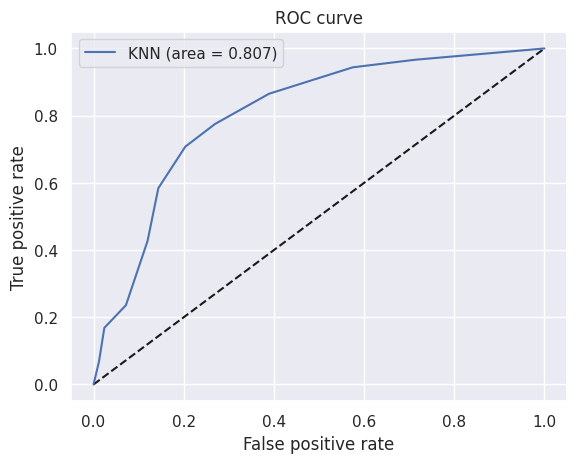

In [46]:
plt.plot([0,1], [0,1], 'k--')
plt.plot(fpr, tpr, label='KNN (area = {:.3f})'.format(auc))
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='best')
plt.show()

### **Implementing** **GridSearchCV**

In [47]:
# In case of classifier like KNN the parameter to be tuned is n_neighbors
param_grid = {'n_neighbors': np.arange(1, 50)}
knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, param_grid, cv=5)
knn_cv.fit(X,y)

print("Best Score:" + str(knn_cv.best_score_))
print("Best Parameters: " + str(knn_cv.best_params_))

Best Score:0.7748068924539513
Best Parameters: {'n_neighbors': np.int64(25)}
